1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

In [1]:
# importing block
import numpy as np
from numpy import random as npr
import pandas as pd
from scipy import linalg as la
from scipy import optimize as sOp
from scipy import stats
from scipy import interpolate as sIn
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from matplotlib import colors as mpc
%matplotlib inline

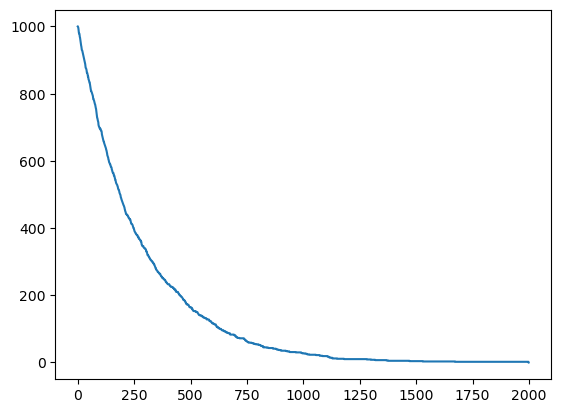

In [30]:
# max time steps
max_t = 2000
# max Thallium atoms
max_T = 1000
# all time samples
time = np.arange(0, max_t, 1, dtype =int )
# Thallium atoms at time t
Thallium = np.zeros(max_t, dtype = int)
Thallium[0] = max_T
# Lead atoms at time t
Lead = np.zeros(max_t, dtype = int)

tau = 3.052 * 60.

# point one: accept reject
def decay_p( t, tau ) :
    return ( 1. - np.power( 2. , - ( t / tau) ) )

# number of dacay each time step
def decay ( Tl, t, tau ) :
    # decay prob
    d = decay_p( t , tau = tau)
    # generate from sampling distribution
    x = np.random.uniform( 0, 1., Tl)
    # generate from uniform distribution
    u = np.random.uniform( 0, 1., Tl)
    # accept-reject criterion for each point in sampling distribution    
    v = u[x < d]
    return len(v)
for i in time[0:-2] :
    decayed = decay( Thallium[i], 1, tau )
    Thallium[i +1] = int(Thallium[i] - decayed)
    Lead[i +1] = int(Lead[i] + decayed)
plt.plot(time, Thallium)

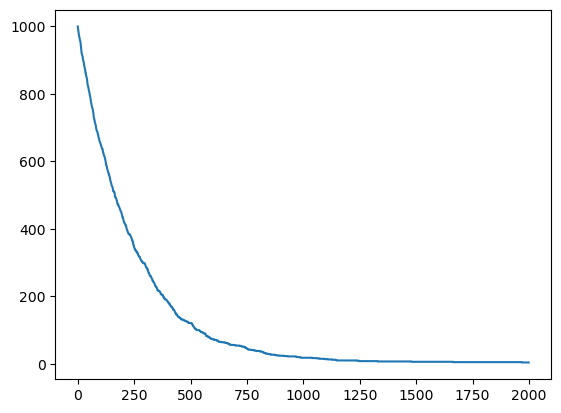

In [32]:
def icf( x , tau ) :
    return - np.log( 2. ) / tau * np.log( 1. - x )
# max Thallium atoms
max_T = 1000
# time steps
t_steps = 1000
# tau
tau = 3.052 * 60.
# generate from uniform distribution
u = np.random.uniform( 0, 1., t_steps )
# time passed
times = icf( u , tau )
o_times = np.sort( times )

#normal_times = np.floor(o_times/o_times[0])
# some magic to normalize to the same value as before
normal_times = np.floor(o_times*max_t/o_times[t_steps - 1 ])
#print(normal_times)
max_time = int(normal_times[t_steps - 1 ])
time_steps = np.arange( max_time )
Tl = np.zeros( max_time )
Tl[0] = max_T
#print( Tl.shape, o_times.shape, time_steps.shape )
for i in range( 1, max_time ) :
    Tl[ i ] = Tl[ i-1 ] - o_times[ normal_times == time_steps[ i ] ].shape[0]
plt.plot( time_steps , Tl )


2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [81]:
# Bohr Radiud in 1/eV
a_0 = 2.68e-4
# Energy used in eV
E = 7.7e6
# std of the 2D gaussian
sigma = a_0/100.
# number of alpha particles
N_alpha = 1e6
# atomic number of gold
Z_Au = 79
# vacuum permittivity (atomic)
# epsilon_0 = 1. / ( 4. * np.pi )
# fine-structure constant
alpha = 1. / 137.036
# electric charge (natural)
# e = np.sqrt( 4. * np.pi * alpha )

# # compute tangent of \theta/2
# def tan_t( Z, E, X ) :
#     # reminder hypot is hypotenuse x^2+y^2
#     # return ( Z / ( 2. * np.pi * epsilon_0 * E * np.hypot( X[0], X[1] ) ) )
#     return ( Z / ( 0.5 * E * np.hypot( X[0], X[1] ) ) )

# compute tangent of \theta/2
def tan_t( Z, E, R ) :
    return ( Z * alpha / ( 0.5 * E * R ) ) 

# fixing seed
npr.seed(42069)

# define radiai using Box-Muller
a = npr.random( int(N_alpha) )
R = np.sqrt( - 2. * np.power( sigma , 2. ) * np.log( a ) )
tangs = tan_t( Z_Au, E, R )
print( f" Fraction of \"bounce back\" particles: { tangs[ tangs > 1. ].shape[0] / tangs.shape[0] :.7f} " )

 Fraction of "bounce back" particles: 0.0015660 


3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [90]:
# first point
# same function given as example
def f(x):
    return (np.sin(1/(x*(2-x))))**2

# Monte Carlo integration hit/miss method
N=100000
count=0
for i in range(N):
    # x in range [0;2]
    x=2.*npr.random()
    # y in range [0;1] as it's sin^2
    y=npr.random()
    if y<f(x): count+=1
# the total area is 1*2
I=2.*count/N

print( f"Hit/Miss result: {I:.5f}; error:" )

# second point
# generating N random points in the domain
X = 2. * npr.random(N)
# evalueted function
F = f( X )
# normalized mean of point
I = ( 2. - 0. ) / N * np.sum( F )
# error
sigma = ( 2. - 0. ) * np.std( F ) / np.sqrt( N )

print( f"Mean result: {I:.5f}; error: {sigma:.5f}" )

Hit/Miss result: 1.45636; error:
Mean result: 1.45129; error: 0.00167


4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere



In [158]:
from scipy.special import gamma
# volume of a n-dim ball
def ball( n ) :
    return np.power( np.pi, ( n / 2. ) ) / gamma( ( n / 2. ) + 1. )

# euclidean norm of any N-D vector
def norm( X ) :
    n = np.sum( np.power( X , 2. ) , axis = 1 ) 
    return n


# indicative function of N-D circle
def circle( X ) :
    c = np.zeros( X.shape[0] )
    c[ norm( X ) <= 1. ] = 1.
    return c

# number of sample
N = 1000000

# dimension of the problem
d = 10

# generating N random points in the domain
x = 1. - 2. * npr.random( ( N , d ) )
# evalueted function
C = circle( x )
# normalized mean of point
I = np.power( ( 1. - -1. ) , d ) / N * np.sum( C )
# error
sigma = np.power( ( 1. - -1. ) , d ) * np.std( C ) / np.sqrt( N )

theory = ball( d )

print( f"Mean result: {I:.5f}; predicted error: {sigma:.5f}; real error: {np.abs((I-theory)/theory):.6f}, real value: {theory:.3f}" )
#plt.scatter( x[ : , 0 ] , x[ : , 1 ], c =C )

Mean result: 2.58765; predicted error: 0.05141; real error: 0.014699, real value: 2.550


5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [176]:
# defining integrand function
def f( x ) : 
    return np.power( x , -0.5 ) / ( np.power( np.e, x ) + 1. )

npr.seed(42069)
# number of points
N = 10000
# generating weighted samples by inverse cumulative of 1/2sqrt(x), a normilized pdf
u = npr.random( N ) 
x = np.power( ( u ), 2. )
F = f( x )
w =  0.5 / np.sqrt( x )
I = np.sum( F / w ) / N 
print( f"Integral value: {I:.5f}")

Integral value: 0.83780
